# CRNN Training

This notebook implements and trains a Convolutional Recurrent Neural Network (CRNN) for Malaysian license plate recognition.

## Objectives

1. Inspect the cropped plate images to choose a sensible input size
2. Configure the CRNN training environment
3. Define the character vocabulary
4. Create the OCR dataset class (with data augmentation for training)
5. Build the CRNN architecture (CNN + BiLSTM + CTC)
6. Train the model with early stopping and a learning-rate scheduler
7. Inspect predictions and evaluate the model
8. Save the best-performing model


In [1]:
import os
import random
import numpy as np

import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt


## Step 1 - Inspect Image Dimensions

Check the size of the cropped plate images before deciding on a fixed input size for the CNN.

In [2]:
image_folder = "OCRDataset/train/images"

widths = []
heights = []

for file in os.listdir(image_folder):
    img = Image.open(os.path.join(image_folder, file))
    widths.append(img.width)
    heights.append(img.height)

print(f"Average Width  : {sum(widths)/len(widths):.2f}")
print(f"Average Height : {sum(heights)/len(heights):.2f}")

print(f"Minimum Size : {min(widths)} x {min(heights)}")
print(f"Maximum Size : {max(widths)} x {max(heights)}")


Average Width  : 143.76
Average Height : 57.33
Minimum Size : 15 x 8
Maximum Size : 611 x 481


## Step 2 - Training Configuration

In [3]:
# =====================================================
# Training Configuration
# =====================================================

# Dataset
TRAIN_CSV = "OCRDataset/train/labels.csv"
VALID_CSV = "OCRDataset/valid/labels.csv"
TEST_CSV  = "OCRDataset/test/labels.csv"

TRAIN_DIR = "OCRDataset/train/images"
VALID_DIR = "OCRDataset/valid/images"
TEST_DIR  = "OCRDataset/test/images"

# Image Size
IMAGE_HEIGHT = 32
IMAGE_WIDTH = 128

# Character Set (Malaysian License Plates)
CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

# Number of classes (+1 for CTC blank)
NUM_CLASSES = len(CHARSET) + 1

# Training Parameters
BATCH_SIZE = 16
NUM_EPOCHS = 100
LEARNING_RATE = 3e-4  # lowered from 1e-3 -- helps avoid CTC collapsing
                      # to a fixed/degenerate output early in training

# Early Stopping
patience = 10

# Scheduler patience is intentionally looser than early-stopping patience.
# If it's tighter (e.g. equal or smaller), the LR gets cut multiple times
# before early stopping even has a chance to fire, which can freeze
# training on a bad plateau instead of letting it push through.
SCHEDULER_PATIENCE = 6

# Checkpoint Path
SAVE_PATH = "best_crnn.pth"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
print(f"Number of Classes : {NUM_CLASSES}")
print(f"Character Set : {CHARSET}")


Device : cuda
Number of Classes : 37
Character Set : 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ


## Step 3 - Character Encoding

In [4]:
# =====================================================
# Character Encoding
# =====================================================

# CTC Blank Token
CTC_BLANK = 0

# Character -> Index
# (Start from 1 because 0 is reserved for CTC Blank)
char_to_idx = {
    char: idx + 1
    for idx, char in enumerate(CHARSET)
}

# Index -> Character
idx_to_char = {
    idx + 1: char
    for idx, char in enumerate(CHARSET)
}

print("Character Mapping")
print("------------------------------")

for char in list(CHARSET)[:10]:
    print(f"{char} -> {char_to_idx[char]}")

print("...")
print("------------------------------")
print(f"CTC Blank Index : {CTC_BLANK}")
print(f"Total Characters: {len(CHARSET)}")
print(f"NUM_CLASSES     : {NUM_CLASSES}")


Character Mapping
------------------------------
0 -> 1
1 -> 2
2 -> 3
3 -> 4
4 -> 5
5 -> 6
6 -> 7
7 -> 8
8 -> 9
9 -> 10
...
------------------------------
CTC Blank Index : 0
Total Characters: 36
NUM_CLASSES     : 37


## Step 4 - Custom Collate Function

Defined early (before the Dataset/DataLoader steps) since the DataLoaders created later need to reference it. Keeping it here avoids the "NameError: collate_fn is not defined" ordering bug.

In [5]:
# =====================================================
# Custom Collate Function
# =====================================================

def collate_fn(batch):

    images = []
    labels = []
    label_lengths = []

    for image, label in batch:

        images.append(image)

        labels.extend(label.tolist())

        label_lengths.append(len(label))

    images = torch.stack(images)

    labels = torch.tensor(
        labels,
        dtype=torch.long
    )

    label_lengths = torch.tensor(
        label_lengths,
        dtype=torch.long
    )

    return images, labels, label_lengths


## Step 5 - Custom OCR Dataset

A custom PyTorch `Dataset` class that prepares the OCR training data. Responsible for:

- Loading image filenames and labels from `labels.csv`
- Reading license plate images from the dataset directory
- Resizing images while preserving aspect ratio
- Padding images to a fixed input size of **32 x 128**
- Applying light data augmentation (training set only)
- Encoding license plate text into numerical indices

In [6]:
# =====================================================
# License Plate Dataset
# =====================================================

class LicensePlateDataset(Dataset):

    def __init__(self, csv_file, image_dir, augment=False):

        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.augment = augment

        # Augmentation only applied to training images.
        # Kept mild since license plate text must stay readable.
        self.augment_transform = transforms.Compose([
            transforms.RandomApply(
                [transforms.RandomRotation(degrees=5, fill=0)],
                p=0.5
            ),
            transforms.RandomApply(
                [transforms.ColorJitter(brightness=0.3, contrast=0.3)],
                p=0.5
            ),
            transforms.RandomApply(
                [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
                p=0.3
            ),
        ])

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])


    def __len__(self):
        return len(self.df)


    def resize_and_pad(self, image):

        width, height = image.size

        scale = min(
            IMAGE_WIDTH / width,
            IMAGE_HEIGHT / height
        )

        new_width = int(width * scale)
        new_height = int(height * scale)

        image = image.resize(
            (new_width, new_height),
            Image.BILINEAR
        )

        canvas = Image.new(
            "L",
            (IMAGE_WIDTH, IMAGE_HEIGHT),
            color=0
        )

        x_offset = (IMAGE_WIDTH - new_width) // 2
        y_offset = (IMAGE_HEIGHT - new_height) // 2

        canvas.paste(
            image,
            (x_offset, y_offset)
        )

        return canvas


    def encode_label(self, label):

        encoded = []

        for char in label:

            if char not in char_to_idx:
                raise ValueError(
                    f"Unsupported character '{char}'"
                )

            encoded.append(char_to_idx[char])

        return encoded


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        filename = row["filename"]
        label = row["label"]

        image_path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(image_path).convert("L")

        image = self.resize_and_pad(image)

        if self.augment:
            image = self.augment_transform(image)

        image = self.transform(image)

        label = self.encode_label(label)

        return image, torch.tensor(label)


## Step 6 - Test Dataset Class

In [7]:
dataset = LicensePlateDataset(TRAIN_CSV, TRAIN_DIR)

print(dataset.encode_label("WB8274L"))
print(dataset.encode_label("ABC123"))


[33, 12, 9, 3, 8, 5, 22]
[11, 12, 13, 2, 3, 4]


## Step 7 - Create Dataset Objects

Augmentation is enabled only for the training set. Validation and test sets stay clean so evaluation reflects real-world performance.

In [8]:
train_dataset = LicensePlateDataset(
    TRAIN_CSV,
    TRAIN_DIR,
    augment=True   # augmentation ON for training only
)

valid_dataset = LicensePlateDataset(
    VALID_CSV,
    VALID_DIR
)

test_dataset = LicensePlateDataset(
    TEST_CSV,
    TEST_DIR
)

print("Train :", len(train_dataset))
print("Validation :", len(valid_dataset))
print("Test :", len(test_dataset))


Train : 720
Validation : 90
Test : 90


## Step 8 - Inspect One Sample

Inspect a single sample from the training dataset to verify that the preprocessing pipeline works correctly.

In [9]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Image Type  :", image.dtype)
print("Label Tensor:", label)
print("Label Length:", len(label))


Image Shape : torch.Size([1, 32, 128])
Image Type  : torch.float32
Label Tensor: tensor([27, 21, 16,  6,  6,  6,  9])
Label Length: 7


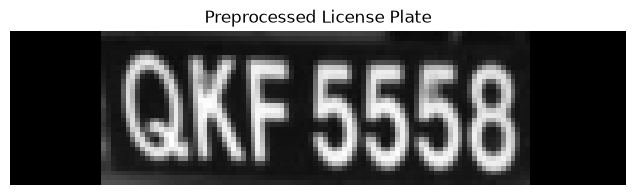

In [10]:
plt.figure(figsize=(8,2))
plt.imshow(image.squeeze().cpu(), cmap="gray")
plt.title("Preprocessed License Plate")
plt.axis("off")
plt.show()


In [11]:
decoded = "".join(idx_to_char[idx.item()] for idx in label)

print("Decoded Label :", decoded)


Decoded Label : QKF5558


## Step 8.1 - Spot-Check Image/Label Alignment

Before training, visually confirm that several random `filename` <-> `label` pairs from the CSV actually match the cropped image content. A single systematic mismatch here (e.g. CSV rows built in a different order than the image files) is enough to make the CTC model collapse to a constant/degenerate output, since it would be trained on contradictory signal.

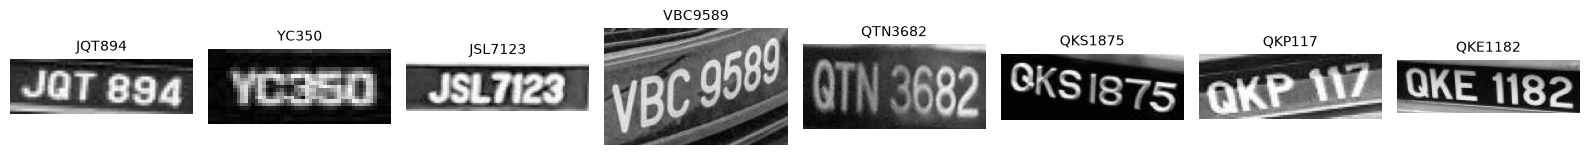

Look closely: does the title (label from CSV) match what the plate
in each image actually shows? Re-run this cell a few times to check
more random samples across the dataset.


In [12]:
# =====================================================
# Spot-Check Random Samples (Image vs Label)
# =====================================================

import random as _random

NUM_SPOTCHECK = 8
sample_indices = _random.sample(range(len(train_dataset.df)), NUM_SPOTCHECK)

fig, axes = plt.subplots(1, NUM_SPOTCHECK, figsize=(NUM_SPOTCHECK * 2, 3))

for ax, idx in zip(axes, sample_indices):

    row = train_dataset.df.iloc[idx]
    filename = row["filename"]
    label = row["label"]

    image_path = os.path.join(TRAIN_DIR, filename)
    image = Image.open(image_path).convert("L")

    ax.imshow(image, cmap="gray")
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Look closely: does the title (label from CSV) match what the plate")
print("in each image actually shows? Re-run this cell a few times to check")
print("more random samples across the dataset.")


## Step 9 - Create DataLoaders

Create PyTorch DataLoaders to efficiently load batches of training, validation, and testing data during CRNN training.

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)


In [14]:
print("Training batches :", len(train_loader))
print("Validation batches :", len(valid_loader))
print("Testing batches :", len(test_loader))


Training batches : 45
Validation batches : 6
Testing batches : 6


## Step 10 - Define the CRNN Model

Implement a Convolutional Recurrent Neural Network (CRNN) consisting of:

- CNN feature extractor
- Bidirectional LSTM sequence model
- Fully connected classification layer

In [15]:
# =====================================================
# CRNN Model
# =====================================================

class CRNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # =================================================
        # CNN Feature Extractor
        # =================================================

        self.cnn = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Block 4
            nn.Conv2d(
                in_channels=256,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1), stride=(2,1)),

            # Block 5
            nn.Conv2d(
                in_channels=256,
                out_channels=512,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # Block 6
            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1), stride=(2,1)),

            # Final Convolution
            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=2,
                stride=1,
                padding=0
            ),
            nn.ReLU(inplace=True)
        )

        # =================================================
        # Bidirectional LSTM
        # =================================================

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        # =================================================
        # Fully Connected Layer
        # =================================================

        self.fc = nn.Linear(
            in_features=512,
            out_features=num_classes
        )

    # =====================================================
    # Forward Pass
    # =====================================================

    def forward(self, x):

        # -----------------------------
        # CNN Feature Extraction
        # -----------------------------
        x = self.cnn(x)

        # Shape:
        # (Batch, Channels, Height, Width)

        batch_size, channels, height, width = x.size()

        # Height should be 1
        assert height == 1, f"Expected feature map height = 1, but got {height}"

        # Remove Height Dimension
        # (B, C, 1, W) -> (B, C, W)
        x = x.squeeze(2)

        # Rearrange for LSTM
        # (B, C, W) -> (B, W, C)
        x = x.permute(0, 2, 1)

        # -----------------------------
        # BiLSTM
        # -----------------------------
        x, _ = self.rnn(x)

        # -----------------------------
        # Character Classification
        # -----------------------------
        x = self.fc(x)

        return x


## Step 11 - Test CRNN Model

Verify that the CRNN model can successfully process an input image and produce an output tensor with the expected dimensions before training.

In [16]:
# =====================================================
# Create CRNN Model
# =====================================================

model = CRNN(NUM_CLASSES).to(DEVICE)

print(model)


CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (

In [17]:
# =====================================================
# Test Forward Pass
# =====================================================

dummy_input = torch.randn(
    1,
    1,
    IMAGE_HEIGHT,
    IMAGE_WIDTH
).to(DEVICE)

output = model(dummy_input)

print("Input Shape :", dummy_input.shape)
print("Output Shape:", output.shape)


Input Shape : torch.Size([1, 1, 32, 128])
Output Shape: torch.Size([1, 31, 37])


## Step 12 - Define CTC Loss

Connectionist Temporal Classification (CTC) Loss is used for sequence recognition tasks where the input sequence length and output label length are different.

Unlike Cross Entropy Loss, CTC does not require character-level alignment. It automatically learns the alignment between image features and the target license plate characters.

In [18]:
# =====================================================
# CTC Loss
# =====================================================

criterion = nn.CTCLoss(
    blank=0,
    reduction="mean",
    zero_infinity=True
)

print("CTC Loss Created Successfully!")


CTC Loss Created Successfully!


## Step 13 - Optimizer and Learning Rate Scheduler

The Adam optimizer is used for efficient gradient-based optimization, while `ReduceLROnPlateau` reduces the learning rate when validation loss stops improving.

`SCHEDULER_PATIENCE` (from Step 2) is deliberately looser than the early-stopping `patience`, so the LR isn't slashed multiple times before early stopping even gets a chance to fire.

In [19]:
# =====================================================
# Optimizer
# =====================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

# =====================================================
# Learning Rate Scheduler
# =====================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=SCHEDULER_PATIENCE,
    min_lr=1e-6
)

print("Optimizer :", optimizer.__class__.__name__)
print("Learning Rate :", optimizer.param_groups[0]["lr"])
print("Scheduler Patience :", SCHEDULER_PATIENCE)


Optimizer : Adam
Learning Rate : 0.0003
Scheduler Patience : 6


## Step 14 - Train CRNN

Run the full training loop with mixed precision, validation, best-model checkpointing, and early stopping.

The training state (`best_val_loss`, `patience_counter`, loss history, `scaler`) is reset at the very top of this cell every time it runs - even if you re-run just this cell on its own - so a previous run can never leave behind a stale `patience_counter` that triggers instant early stopping.

In [20]:
# =====================================================
# Train CRNN
# =====================================================

from tqdm import tqdm
from collections import deque
from IPython.display import clear_output

# ---------------------------------------------------
# Reset Training State
# (always runs here, so this cell is safe to re-run
#  standalone without needing a separate reset cell)
# ---------------------------------------------------
best_val_loss = float("inf")
patience_counter = 0
train_losses = []
valid_losses = []

scaler = torch.amp.GradScaler(
    device=DEVICE.type,
    enabled=(DEVICE.type == "cuda")
)

recent_logs = deque(maxlen=3)

print("=" * 60)
print("Starting CRNN Training")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    ####################################################
    # Training
    ####################################################

    model.train()

    train_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]",
        leave=False
    )

    for images, labels, label_lengths in progress_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        label_lengths = label_lengths.to(DEVICE)

        optimizer.zero_grad()

        ################################################
        # Forward
        ################################################

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=(DEVICE.type == "cuda")
        ):

            outputs = model(images)

            log_probs = outputs.log_softmax(2)

            log_probs = log_probs.permute(1, 0, 2)

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=log_probs.size(0),
                dtype=torch.long,
                device=DEVICE
            )

            loss = criterion(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )

        ################################################
        # Backpropagation
        ################################################

        scaler.scale(loss).backward()

        # Gradient clipping -- helps prevent the optimizer from
        # taking a step so large it collapses onto a degenerate,
        # input-independent output (a known CTC failure mode).
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    ####################################################
    # Average Training Loss
    ####################################################

    train_loss /= len(train_loader)

    train_losses.append(train_loss)

    ####################################################
    # Validation
    ####################################################

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images, labels, label_lengths in valid_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            label_lengths = label_lengths.to(DEVICE)

            outputs = model(images)

            log_probs = outputs.log_softmax(2)

            log_probs = log_probs.permute(1, 0, 2)

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=log_probs.size(0),
                dtype=torch.long,
                device=DEVICE
            )

            loss = criterion(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )

            val_loss += loss.item()

    val_loss /= len(valid_loader)

    valid_losses.append(val_loss)

    ####################################################
    # Step LR Scheduler
    ####################################################

    scheduler.step(val_loss)

    ####################################################
    # Save Best Model
    ####################################################

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        torch.save(
            model.state_dict(),
            SAVE_PATH
        )

        status = "New Best Model Saved"

    else:

        patience_counter += 1

        status = f"No Improvement ({patience_counter}/{patience})"

    ####################################################
    # Build This Epoch's Log Block
    ####################################################

    log_block = []
    log_block.append("-" * 60)
    log_block.append(f"Epoch {epoch+1:03d}/{NUM_EPOCHS}")
    log_block.append("-" * 60)
    log_block.append(f"Train Loss      : {train_loss:.4f}")
    log_block.append(f"Validation Loss : {val_loss:.4f}")
    log_block.append(f"Best Loss       : {best_val_loss:.4f}")
    log_block.append(f"Learning Rate   : {optimizer.param_groups[0]['lr']:.6f}")
    log_block.append(f"Status          : {status}")
    log_block.append("-" * 60)

    recent_logs.append("\n".join(log_block))

    ####################################################
    # Clear Screen & Print Only Latest 3 Epochs
    ####################################################

    clear_output(wait=True)

    print("=" * 60)
    print("Starting CRNN Training")
    print("=" * 60)

    for block in recent_logs:
        print("\n" + block)

    ####################################################
    # Early Stopping
    ####################################################

    if patience_counter >= patience:

        print("\n" + "=" * 60)
        print("Early Stopping Triggered")
        print("=" * 60)

        break

print("\n" + "=" * 60)
print("Training Finished")
print("=" * 60)
print(f"Best Validation Loss : {best_val_loss:.4f}")
print(f"Best Model Saved At  : {SAVE_PATH}")


Starting CRNN Training

------------------------------------------------------------
Epoch 065/100
------------------------------------------------------------
Train Loss      : 0.4457
Validation Loss : 2.0012
Best Loss       : 1.9340
Learning Rate   : 0.000150
Status          : No Improvement (8/10)
------------------------------------------------------------

------------------------------------------------------------
Epoch 066/100
------------------------------------------------------------
Train Loss      : 0.3905
Validation Loss : 2.0962
Best Loss       : 1.9340
Learning Rate   : 0.000150
Status          : No Improvement (9/10)
------------------------------------------------------------

------------------------------------------------------------
Epoch 067/100
------------------------------------------------------------
Train Loss      : 0.3670
Validation Loss : 2.0786
Best Loss       : 1.9340
Learning Rate   : 0.000150
Status          : No Improvement (10/10)
-----------------

## Step 15 - Plot Training / Validation Loss

Run this after training to check whether the model is overfitting (train loss keeps dropping while val loss flattens/rises) or genuinely plateauing (both flatten together).

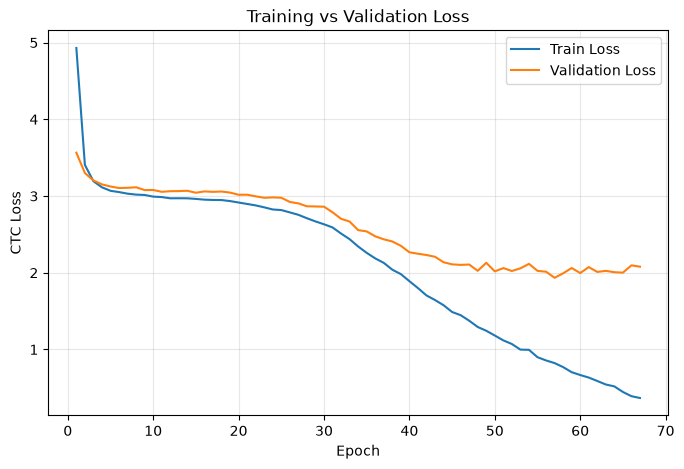

Best epoch            : 57
Best validation loss  : 1.9340
Final train loss      : 0.3670
Final validation loss : 2.0786


In [21]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_epoch = valid_losses.index(min(valid_losses)) + 1
print(f"Best epoch            : {best_epoch}")
print(f"Best validation loss  : {min(valid_losses):.4f}")
print(f"Final train loss      : {train_losses[-1]:.4f}")
print(f"Final validation loss : {valid_losses[-1]:.4f}")


## Step 16 - Greedy CTC Decoding

A CTC model outputs a probability distribution over characters (plus blank) for every timestep. To turn that into readable text:

1. Take the most likely character at each timestep (argmax)
2. Collapse repeated consecutive characters (e.g. "AA11" -> "A1")
3. Remove blank tokens

This is the standard greedy decoding used to sanity-check what the model is actually predicting - useful for spotting failure modes like the model collapsing to mostly-blank output.

In [22]:
def ctc_greedy_decode(log_probs):
    """
    log_probs: Tensor of shape (T, num_classes) for a single sample
    (already log-softmaxed).
    Returns the decoded string.
    """

    pred_indices = torch.argmax(log_probs, dim=1).tolist()

    decoded_chars = []
    previous = None

    for idx in pred_indices:

        if idx != previous and idx != CTC_BLANK:
            decoded_chars.append(idx_to_char[idx])

        previous = idx

    return "".join(decoded_chars)


## Step 17 - Inspect Predictions on Validation Samples

Load the best saved checkpoint and look at real predicted text vs. ground truth. This directly checks for the "model collapsed to blank / repeated character" failure mode that a loss curve alone can't show.

In [23]:
# =====================================================
# Load Best Checkpoint
# =====================================================

inspect_model = CRNN(NUM_CLASSES).to(DEVICE)
inspect_model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
inspect_model.eval()

print(f"Loaded best checkpoint from: {SAVE_PATH}")


Loaded best checkpoint from: best_crnn.pth


In [24]:
# =====================================================
# Show Predictions vs Ground Truth
# =====================================================

NUM_SAMPLES_TO_SHOW = 10

with torch.no_grad():

    images, labels, label_lengths = next(iter(valid_loader))

    images = images.to(DEVICE)

    outputs = inspect_model(images)

    log_probs = outputs.log_softmax(2)

    # Reconstruct ground-truth strings from the flattened label tensor
    ground_truths = []
    pointer = 0
    for length in label_lengths.tolist():
        chars = labels[pointer:pointer + length].tolist()
        ground_truths.append("".join(idx_to_char[c] for c in chars))
        pointer += length

    correct = 0

    for i in range(min(NUM_SAMPLES_TO_SHOW, images.size(0))):

        predicted = ctc_greedy_decode(log_probs[i].cpu())
        actual = ground_truths[i]

        match = "CORRECT" if predicted == actual else "WRONG"

        if predicted == actual:
            correct += 1

        print(f"Predicted: {predicted:<12} | Actual: {actual:<12} | {match}")

print()
print(f"Exact match on this batch: {correct}/{min(NUM_SAMPLES_TO_SHOW, images.size(0))}")


Predicted: WC905        | Actual: WOR1906      | WRONG
Predicted: P240         | Actual: MHN7240      | WRONG
Predicted: WC881        | Actual: MCE8819      | WRONG
Predicted: VBW8993      | Actual: WWV8993      | WRONG
Predicted: CE18920      | Actual: CEM1880      | WRONG
Predicted: JRP6937      | Actual: JPF6937      | WRONG
Predicted: WEG1678      | Actual: IIUM6763     | WRONG
Predicted: WMN5716      | Actual: BEL3716      | WRONG
Predicted: WA51         | Actual: W4614W       | WRONG
Predicted: JC3131       | Actual: JKG3131      | WRONG

Exact match on this batch: 0/10


## Step 18 - Evaluate on Test Set

Run the best checkpoint across the full held-out test set and compute exact-match accuracy (whole plate predicted correctly) and character-level accuracy.

In [25]:
# =====================================================
# Full Test Set Evaluation
# =====================================================

total_plates = 0
correct_plates = 0

total_chars = 0
correct_chars = 0

with torch.no_grad():

    for images, labels, label_lengths in test_loader:

        images = images.to(DEVICE)

        outputs = inspect_model(images)

        log_probs = outputs.log_softmax(2)

        pointer = 0

        for i in range(images.size(0)):

            length = label_lengths[i].item()

            chars = labels[pointer:pointer + length].tolist()
            actual = "".join(idx_to_char[c] for c in chars)
            pointer += length

            predicted = ctc_greedy_decode(log_probs[i].cpu())

            total_plates += 1

            if predicted == actual:
                correct_plates += 1

            # Character-level comparison (position-by-position, up to
            # the length of the shorter string)
            min_len = min(len(predicted), len(actual))

            for j in range(min_len):
                total_chars += 1
                if predicted[j] == actual[j]:
                    correct_chars += 1

            total_chars += abs(len(predicted) - len(actual))

plate_accuracy = correct_plates / total_plates * 100
char_accuracy = correct_chars / total_chars * 100 if total_chars > 0 else 0.0

print("=" * 50)
print("Test Set Evaluation")
print("=" * 50)
print(f"Total Plates          : {total_plates}")
print(f"Exact Match Accuracy  : {plate_accuracy:.2f}%  ({correct_plates}/{total_plates})")
print(f"Character Accuracy     : {char_accuracy:.2f}%")


Test Set Evaluation
Total Plates          : 90
Exact Match Accuracy  : 5.56%  (5/90)
Character Accuracy     : 43.88%
